In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans

%matplotlib inline

In [2]:
df=pd.read_csv("../data/mall_customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.shape

(200, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [7]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


# Data Exploration

The Mall Customer dataset contains customer demographic and spending behavior information. The objective is to segment customers into groups using K-Means clustering.

In [8]:
df.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [9]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [10]:
df["Genre"].value_counts()

Genre
Female    112
Male       88
Name: count, dtype: int64

## Gender Distribution

This section analyzes the number of male and female customers present in the dataset.

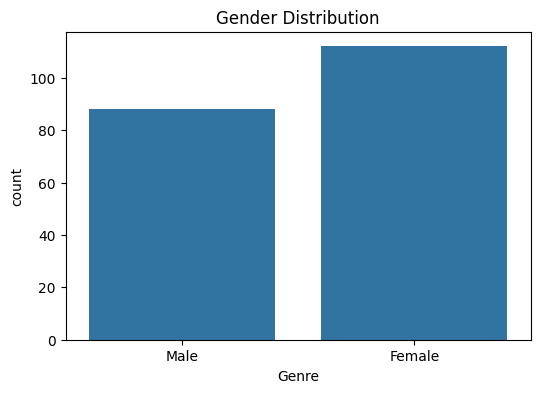

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(x="Genre", data=df)

plt.title("Gender Distribution")
plt.savefig("../images/gender_distribution.png")
plt.show()

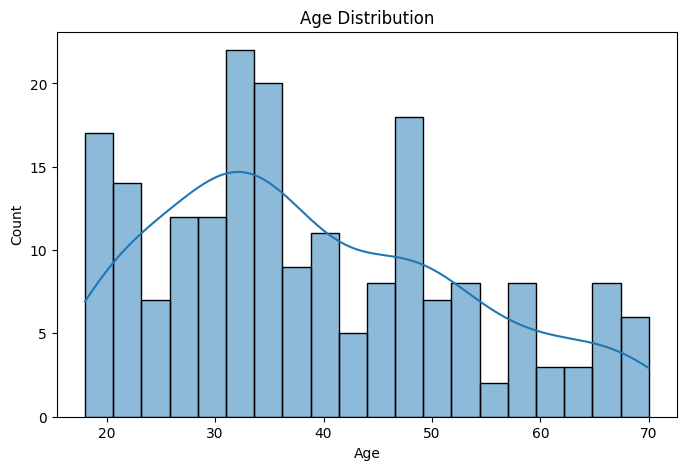

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Age Distribution")
plt.savefig("../images/age_distribution.png")
plt.show()

## Age Distribution

This visualization shows the distribution of customer ages.

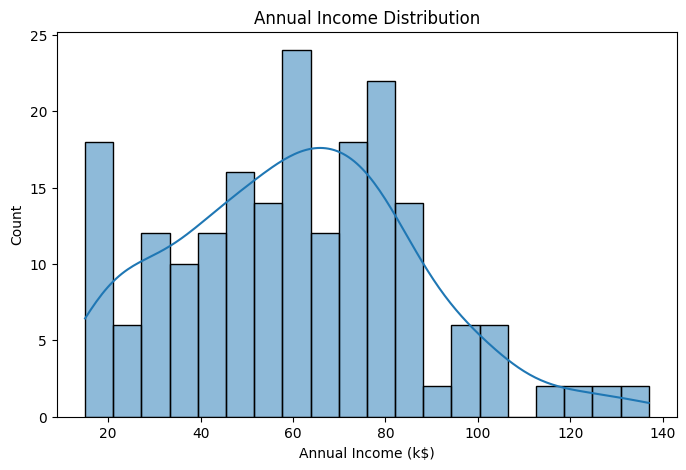

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df["Annual Income (k$)"], bins=20, kde=True)

plt.title("Annual Income Distribution")
plt.savefig("../images/income_distribution.png")
plt.show()

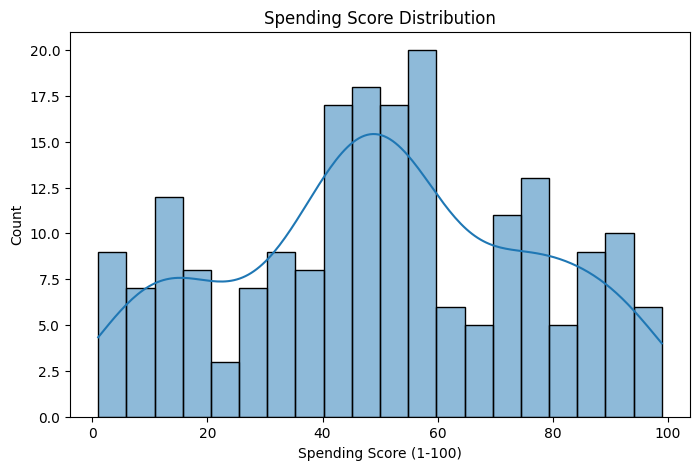

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df["Spending Score (1-100)"], bins=20, kde=True)

plt.title("Spending Score Distribution")
plt.savefig("../images/spending_score_distribution.png")
plt.show()

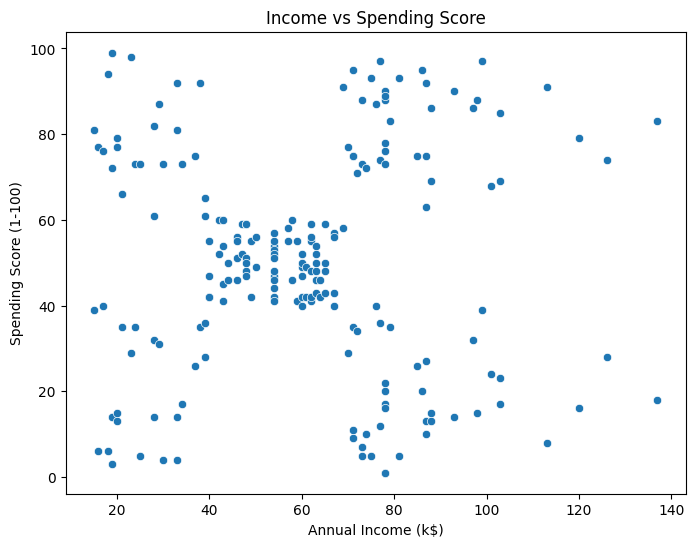

In [15]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    data=df
)

plt.title("Income vs Spending Score")
plt.savefig("../images/income_vs_spending.png")
plt.show()

## Income vs Spending Score

This scatter plot helps identify patterns between annual income and spending behavior.

In [16]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

In [17]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init="k-means++",
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

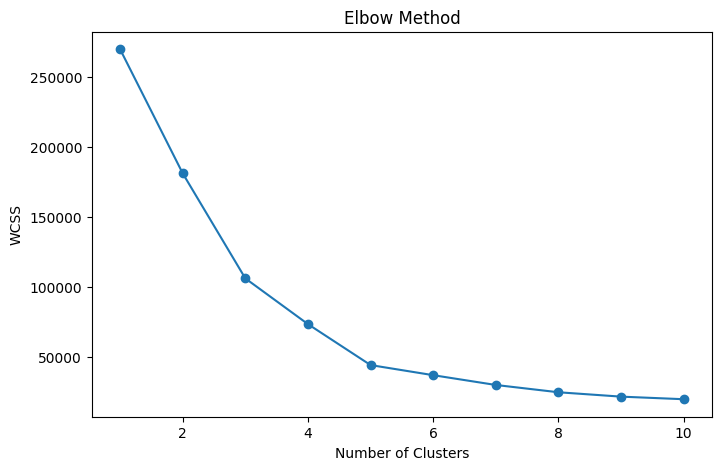

In [18]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.savefig("../images/elbow_method.png")
plt.show()

In [19]:
kmeans = KMeans(
    n_clusters=5,
    init="k-means++",
    random_state=42,
    n_init=10
)

y_kmeans = kmeans.fit_predict(X)

In [20]:
df["Cluster"] = y_kmeans

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


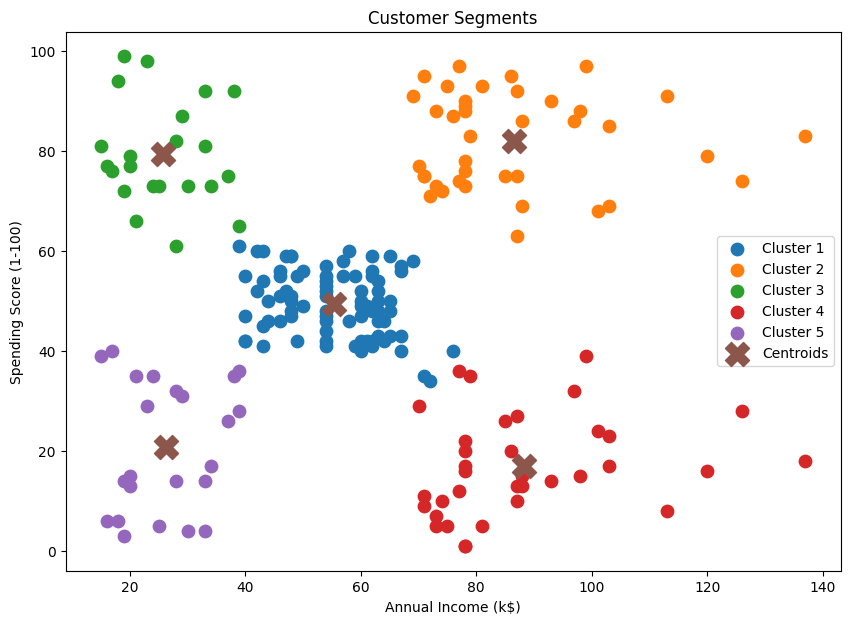

In [21]:
plt.figure(figsize=(10,7))

plt.scatter(
    X.iloc[y_kmeans == 0, 0],
    X.iloc[y_kmeans == 0, 1],
    s=80,
    label="Cluster 1"
)

plt.scatter(
    X.iloc[y_kmeans == 1, 0],
    X.iloc[y_kmeans == 1, 1],
    s=80,
    label="Cluster 2"
)

plt.scatter(
    X.iloc[y_kmeans == 2, 0],
    X.iloc[y_kmeans == 2, 1],
    s=80,
    label="Cluster 3"
)

plt.scatter(
    X.iloc[y_kmeans == 3, 0],
    X.iloc[y_kmeans == 3, 1],
    s=80,
    label="Cluster 4"
)

plt.scatter(
    X.iloc[y_kmeans == 4, 0],
    X.iloc[y_kmeans == 4, 1],
    s=80,
    label="Cluster 5"
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    marker="X",
    label="Centroids"
)

plt.title("Customer Segments")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()

plt.savefig("../images/customer_segments.png")

plt.show()

In [22]:
df.groupby("Cluster")[
    ["Annual Income (k$)", "Spending Score (1-100)", "Age"]
].mean()

,Annual Income (k$),Spending Score (1-100),Age
Cluster,,,
0,55.296296,49.518519,42.716049
1,86.538462,82.128205,32.692308
2,25.727273,79.363636,25.272727
3,88.200000,17.114286,41.114286
4,26.304348,20.913043,45.217391


# Customer Segmentation Insights

### Cluster 0 – Average Customers
- Average Income: 55.30 k$
- Average Spending Score: 49.52
- Average Age: 42.72 years

These customers show balanced income and spending behavior and represent regular customers.

### Cluster 1 – High Value Customers
- Average Income: 86.54 k$
- Average Spending Score: 82.13
- Average Age: 32.69 years

These customers have high income and high spending habits. They are the most valuable customer segment and should be targeted with premium offers.

### Cluster 2 – Young High Spenders
- Average Income: 25.73 k$
- Average Spending Score: 79.36
- Average Age: 25.27 years

Despite lower income levels, these customers spend heavily. Marketing campaigns and loyalty programs can be effective for this group.

### Cluster 3 – Wealthy Low Spenders
- Average Income: 88.20 k$
- Average Spending Score: 17.11
- Average Age: 41.11 years

These customers have high income but spend less. Businesses can target them with personalized promotions to increase spending.

### Cluster 4 – Low Value Customers
- Average Income: 26.30 k$
- Average Spending Score: 20.91
- Average Age: 45.22 years

These customers have lower income and lower spending behavior. They contribute less revenue compared to other segments.

# Conclusion

K-Means Clustering successfully segmented customers into five distinct groups based on annual income and spending score.

Key Findings:
- High-income high-spending customers are the most profitable segment.
- Young customers tend to spend more despite lower income levels.
- Some customers have high purchasing power but low spending activity.
- Customer segmentation helps businesses create targeted marketing strategies and improve customer engagement.

The analysis demonstrates how clustering techniques can be used to understand customer behavior and support business decision-making.